In [ ]:
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np
import pathlib
from tqdm.auto import tqdm, trange

DATA_DIR = pathlib.Path.cwd() / "../data"
DATA_DIR

PosixPath('/usr/local/google/home/ericmascot/Documents/G4CMP/examples/RISQTutorial/AnalysisTools/../data')

In [ ]:
fname = DATA_DIR / "mu-_1-1000MeV_0_-1_-1_primary.txt.gz"
primary_init_E_eV = np.loadtxt(fname, skiprows=1, usecols=3)

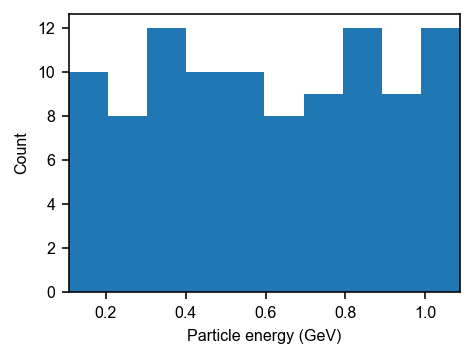

In [ ]:
fig, ax = plt.subplots()
ax.hist(1e-9 * primary_init_E_eV, bins=10)
ax.set_xlabel("Particle energy (GeV)")
ax.set_ylabel("Count")
plt.show()

In [ ]:
def get_charge(name: str) -> int:
    """Return -1 for electron and +1 for holes."""
    if name == b"G4CMPDriftHole":
        return 1
    elif name == b"G4CMPDriftElectron":
        return -1
    else:
        return 0


# Column labels in hits files
labels = [
    "Run ID",
    "Event ID",
    "Track ID",
    "Particle Name",
    "Start Energy [eV]",
    "Start X [mm]",
    "Start Y [mm]",
    "Start Z [mm]",
    "Start Time [ns]",
    "Energy Deposited [eV]",
    "Track Weight",
    "End X [mm]",
    "End Y [mm]",
    "End Z [mm]",
    "Final Time [ns]",
    "Volume Name",
]

fname = DATA_DIR / "mu-_1-1000MeV_0_-1_-1.txt.gz"
data = np.loadtxt(fname, skiprows=1, converters={3: get_charge})
data.shape

(18250493, 15)

In [5]:
ids = data[:, :3].astype(int)
charge = data[:, 3].astype(int)
init_E_eV = data[:, 4]
init_pos_mm = data[:, 5:8]
init_t_ns = data[:, 8]
dE_eV = data[:, 9]
final_pos_mm = data[:, 11:14]
final_t_ns = data[:, 14]

Here is a sample of charges.
It shows only initial and final positions (ignores scattering).

In [ ]:
e_lines = np.stack([init_pos_mm[charge == -1], final_pos_mm[charge == -1]])
h_lines = np.stack([init_pos_mm[charge == 1], final_pos_mm[charge == 1]])

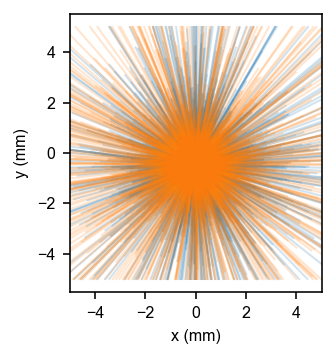

In [ ]:
fig, ax = plt.subplots()
ax.plot(e_lines[:, :10000, 0], e_lines[:, :10000, 1], "C0", alpha=0.2)
ax.plot(h_lines[:, :10000, 0], h_lines[:, :10000, 1], "C1", alpha=0.2)
ax.set_aspect(1)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
plt.show()

Particle/hole asymmetry?

In [8]:
(np.sum(charge > 0) - np.sum(charge < 0)) / len(charge)

-7.123095250084478e-07

The (approximate) velocities are <1% the speed of light

In [ ]:
dx = final_pos_mm - init_pos_mm
dt = final_t_ns - init_t_ns
v = np.linalg.norm(dx, axis=-1) / dt  # mm / ns
v *= 1e-3 / 1e-9  # m/s
c = 299_792_458  # m/s
beta = v[dt > 0] / c

/tmp/ipykernel_3390114/3277783322.py:3: RuntimeWarning: divide by zero encountered in divide
  v = np.linalg.norm(dx, axis=-1) / dt  # mm / ns
/tmp/ipykernel_3390114/3277783322.py:3: RuntimeWarning: invalid value encountered in divide
  v = np.linalg.norm(dx, axis=-1) / dt  # mm / ns


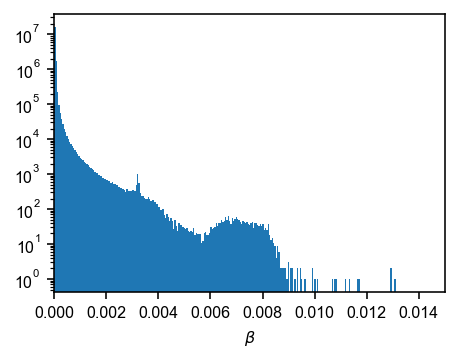

In [ ]:
fig, ax = plt.subplots()
ax.hist(beta, bins=256, log=True)
ax.set_xlabel(r"$\beta$")
ax.set_xlim(0, 0.015)
plt.show()

Most of the charges end at the top or bottom surface

In [ ]:
pos_e = final_pos_mm[charge == -1]
pos_h = final_pos_mm[charge == 1]

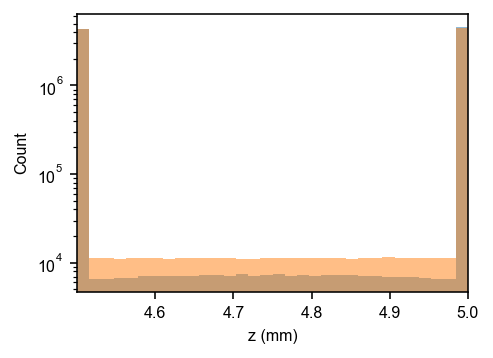

In [ ]:
fig, ax = plt.subplots()
ax.hist(pos_e[:, 2], log=True, alpha=0.5)
ax.hist(pos_h[:, 2], log=True, alpha=0.5)
ax.set_xlabel("z (mm)")
ax.set_ylabel("Count")
plt.show()

In [13]:
print(final_pos_mm.min(axis=0))
print(final_pos_mm.max(axis=0))

[-5.     -5.      4.5001]
[5.     5.     5.0001]


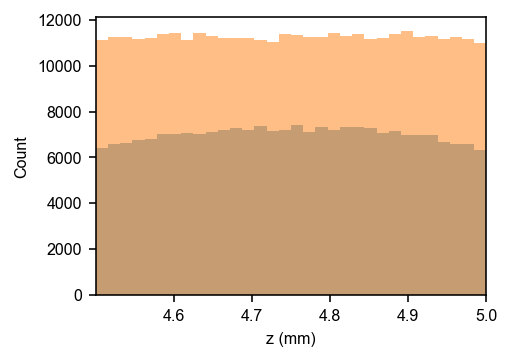

In [ ]:
bulk_e = (pos_e[:, 2] > 4.5001) & (pos_e[:, 2] < 5.0001)
bulk_h = (pos_h[:, 2] > 4.5001) & (pos_h[:, 2] < 5.0001)
fig, ax = plt.subplots()
ax.hist(pos_e[bulk_e, 2], alpha=0.5)
ax.hist(pos_h[bulk_h, 2], alpha=0.5)
ax.set_xlabel("z (mm)")
ax.set_ylabel("Count")
plt.show()

A 2D histogram of e/h final positions and the charge density.
There is an negative charge cloud around the muon impact, surrounded by a positive charge.

In [66]:
step = 0.05
x = np.arange(-5, 5 + step, step)
y = np.arange(-5, 5 + step, step)
z = np.arange(4.5, 5.0001 + step, step)
E = np.linspace(1e6, 1000e6, 33)

In [67]:
# Group by initial energy of primary particle
xyze = np.hstack([final_pos_mm, primary_init_E_eV[ids[:, 1], np.newaxis]])
hist_e, edge_e = np.histogramdd(xyze[charge < 0], (x, y, z, E))
hist_h, edge_h = np.histogramdd(xyze[charge > 0], (x, y, z, E))

In [68]:
e = 1.60217733e-19  # C
rho = e * (hist_h - hist_e) / (1e-3 * step) ** 3  # C / m^3
# top and bottom surface charge density in C / m^2
sigma_t = e * (hist_h[:, :, -1] - hist_e[:, :, -1]) / (1e-3 * step) ** 2
sigma_b = e * (hist_h[:, :, 0] - hist_e[:, :, 0]) / (1e-3 * step) ** 2

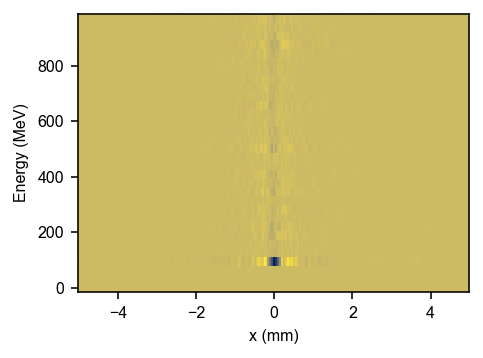

In [69]:
fig, ax = plt.subplots()
ax.pcolormesh(x[:-1], 1e-6 * E[:-1], sigma_b[:, y.size // 2].T)
ax.set_xlabel("x (mm)")
ax.set_ylabel("Energy (MeV)")
plt.show()

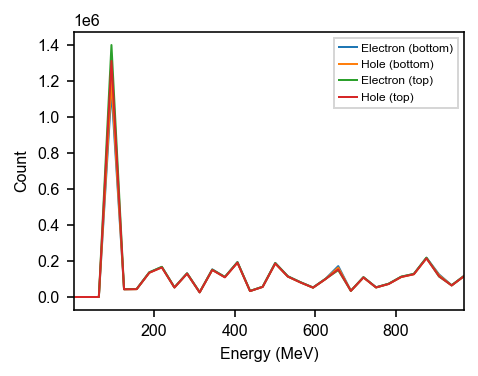

In [75]:
fig, ax = plt.subplots()
ax.plot(1e-6*E[:-1], hist_e[:,:,0].sum(axis=(0, 1)), label="Electron (bottom)")
ax.plot(1e-6*E[:-1], hist_h[:,:,0].sum(axis=(0, 1)), label="Hole (bottom)")
ax.plot(1e-6*E[:-1], hist_e[:,:,-1].sum(axis=(0, 1)), label="Electron (top)")
ax.plot(1e-6*E[:-1], hist_h[:,:,-1].sum(axis=(0, 1)), label="Hole (top)")
ax.legend()
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Count")
plt.show()

In [71]:
@interact(n=(0, len(E) - 2))
def plot_histograms(n=3):
    extent = (-5, 5, -5, 5)
    fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(4, 4))

    kwargs = dict(origin="lower", extent=extent, vmin=1, vmax=6.1e3, norm="log")
    ax[0, 0].imshow(hist_e[:, :, -1, n].T, **kwargs)
    ax[0, 1].imshow(hist_h[:, :, -1, n].T, **kwargs)
    ax[1, 0].imshow(hist_e[:, :, 0, n].T, **kwargs)
    ax[1, 1].imshow(hist_h[:, :, 0, n].T, **kwargs)

    ax[0, 0].set_title("Electron (top)")
    ax[0, 1].set_title("Hole (top)")
    ax[1, 0].set_title("Electron (bottom)")
    ax[1, 1].set_title("Hole (bottom)")

    for a in ax[-1]:
        a.set_xlabel("x (mm)")
    for a in ax[:, 0]:
        a.set_ylabel("y (mm)")

    fig.suptitle(f"Energy {E[n]/1e6:.0f} MeV")
    plt.show()

interactive(children=(IntSlider(value=3, description='n', max=31), Output()), _dom_classes=('widget-interact',…

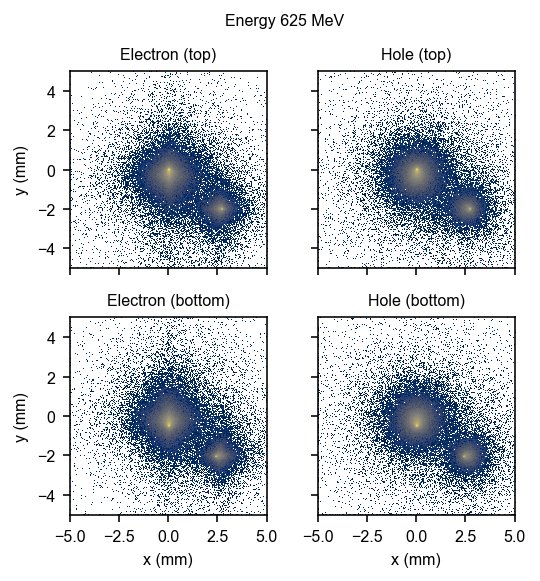

In [28]:
plot_histograms(20)

In [ ]:
@interact(n=(0, len(E) - 2))
def plot_charge(n=0):
    extent = (-5, 5, -5, 5)
    fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(6, 2.5))

    vmax = max(np.abs(sigma_t[..., n]).max(), np.abs(sigma_b[..., n]).max())
    kwargs = dict(origin="lower", extent=extent, vmin=-vmax, vmax=vmax, cmap="RdBu_r")
    im = axs[0].imshow(sigma_t[:, :, n].T, **kwargs)
    fig.colorbar(im, ax=axs[0], label="$C/m^2$")
    im = axs[1].imshow(sigma_b[:, :, n].T, **kwargs)
    fig.colorbar(im, ax=axs[1], label="$C/m^2$")

    axs[0].set_title("Charge density (top)")
    axs[1].set_title("Charge density (bottom)")

    for ax in axs:
        ax.set_xlabel("x (mm)")
    axs[0].set_ylabel("y (mm)")

    fig.suptitle(f"Energy {E[n]/1e6:.0f} MeV")
    plt.show()

interactive(children=(IntSlider(value=0, description='n', max=31), Output()), _dom_classes=('widget-interact',…

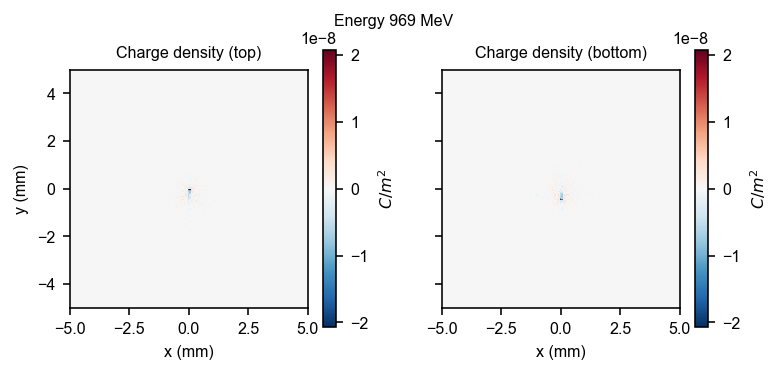

In [30]:
plot_charge(-2)